<a href="https://colab.research.google.com/github/harishmuh/R_tutorial/blob/main/Bioinformatic_analysis_tutorial_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bioinformatic Analysis in R**

## **Introduction**

This notebook highlights the fundamental steps in performing bioinformatic analysis using R, focusing on two main areas:

1.  **Basic Bioinformatic Operations**: This section covers fundamental tasks such as sequence manipulation (e.g., DNA string operations, subsequence extraction, length calculation) using the Biostrings package. It also demonstrates Multiple Sequence Alignment (MSA) of influenza hemagglutinin protein sequences using ClustalW, generating consensus sequences, and constructing phylogenetic trees (Neighbor Joining method) to analyze evolutionary kinship among viral variants.

2.  **Liver Cancer Clinical Data Analysis**: This section focuses on the preprocessing, analysis, and visualization of clinical data from liver cancer patients. It includes steps like data acquisition, handling missing values (NA) by filtering and imputation (median method), checking for duplicate records, performing statistical summaries on single and multiple variables, and creating various visualizations such as pie charts, boxplots, correlation heatmaps, and scatter plots with linear regression analysis.

## **Section 0: Basic sequence operation**

**Initial setup**

Before running the tutorial, we need to prepare setup that includes installing packages and dependencies into this notebook.

In [7]:
# Installing package and dependencies Biocmanager
# please follow Biocmanager package for installation
# https://www.bioconductor.org/packages/release/bioc/html/msa.html
# https://bioconductor.org/packages/release/bioc/html/Biostrings.html

if (!require("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install("msa")
BiocManager::install("Biostrings")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Installing package(s) 'BiocVersion', 'msa'

also installing the dependencies ‘XVector’, ‘Seqinfo’, ‘Biostrings’, ‘BiocGenerics’, ‘IRanges’, ‘S4Vectors’


Old packages: 'backports', 'bit64', 'cli', 'cpp11', 'curl', 'devtools',
  'dplyr', 'ellipsis', 'fs', 'ggplot2', 'glue', 'magrittr', 'nlme', 'openssl',
  'pak', 'pkgload', 'processx', 'ps', 'purrr', 'Rcpp', 'rlang', 'S7', 'vctrs',
  'xtable'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-0

In [1]:
# Installing all required packages if not yet installed
# How to install: install.packages('library_name')
install.packages("rmarkdown")
install.packages("knitr")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")
install.packages("reshape2")
install.packages("RColorBrewer")
install.packages("seqinr")
install.packages("ape")
#install.packages("Biostrings")
#install.packages("msa")
#install.packages("BiocManager")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘pixmap’, ‘sp’, ‘RcppArmadillo’, ‘ade4’, ‘segmented’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [8]:
# Check the package installation
# How to check: "libraryname" %in% rownames(installed.packages())
# make sure all packages have TRUE status.

"rmarkdown" %in% rownames(installed.packages())
"knitr" %in% rownames(installed.packages())
"ggplot2" %in% rownames(installed.packages())
"dplyr" %in% rownames(installed.packages())
"tidyr" %in% rownames(installed.packages())
"reshape2" %in% rownames(installed.packages())
"RColorBrewer" %in% rownames(installed.packages())
"seqinr" %in% rownames(installed.packages())
"ape" %in% rownames(installed.packages())
"Biostrings" %in% rownames(installed.packages())
"ape" %in% rownames(installed.packages())
"msa" %in% rownames(installed.packages())
"BiocManager" %in% rownames(installed.packages())

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

...

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

Now, we will do the basic of bioinformatic operation with R.

For example, there is a sequence with the following order:

"GCAGGAAATCG-GACAGAAGCAGTC-CAAGCTTTAT--TCTTG"

We will place the sequence into variable and calculate the length of the sequence


In [9]:
# Basic DNA sequence operation

# Load the Biostrings package
library(Biostrings)

# Enter the data as DNA string data
z <- DNAString("GCAGGAAATCG-GACAGAAGCAGTC-CAAGCTTTAT--TCTTG")
z

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

43-letter DNAString object
seq: GCAGGAAATCG-GACAGAAGCAGTC-CAAGCTTTAT--TCTTG

In [14]:
# Display the 13th order of the sequence
z[13]

1-letter DNAString object
seq: G

In [11]:
# Display the sequence from 9 to 17
z[9:17]

9-letter DNAString object
seq: TCG-GACAG

In [13]:
# Create an output like the image below with the sequence starting from 5-1 and ending from 9-13.
Views(z, start=5:1, end=9:13)


Views on a 43-letter DNAString subject
subject: GCAGGAAATCG-GACAGAAGCAGTC-CAAGCTTTAT--TCTTG
views:
      start end width
  [1]     5   9     5 [GAAAT]
  [2]     4  10     7 [GGAAATC]
  [3]     3  11     9 [AGGAAATCG]
  [4]     2  12    11 [CAGGAAATCG-]
  [5]     1  13    13 [GCAGGAAATCG-G]

In [18]:
# Create a subsequence of the sequence with sequence 1 ending at sequence 23 and sequence 2 starting at sequence 24

s1 <- subseq(z, end=23)
s2 <- subseq(z, start=24)

print(s1)
print(s2)

23-letter DNAString object
seq: GCAGGAAATCG-GACAGAAGCAG
20-letter DNAString object
seq: TC-CAAGCTTTAT--TCTTG


In [19]:
# Length of sequence
length(s1)
length(s2)

[1] 23

[1] 20

## **Section 1: Data preprocessing of Liver Cancer Clinical Data**  

Viki is provided with clinical data of liver cancer patients from the Memorial Sloan Kettering (MSK) global study on the bioportal dataset (https://www.cbioportal.org/).

Please, help Viki analyze the data, starting with data preprocessing, which includes Obtaining the dataset, handling NA values, and handling duplicate data.

**Setting working directory**

In [21]:
# Setting work directory
setwd('/content/sample_data')

In [22]:
# Checking the location of working directory
getwd()

[1] "/content/sample_data"

**Obtaining the dataset**

Now, we will download the dataset and place the dataset into local_file_path in our working directory

In [23]:
# Downloading dataset
# URL for the hcc_msk_2024_clinical_data.tsv file
url_github <- 'https://raw.githubusercontent.com/harishmuh/R_tutorial/refs/heads/main/datasets/hcc_msk_2024_clinical_data.tsv'

# Define the local file path where we want to save the dataset
local_file_path <- 'hcc_msk_2024_clinical_data.tsv'

# Download the file
download.file(url_github, destfile = local_file_path, method = 'auto')

**Reading file**

In [24]:
# Read the downloaded TSV file from the local path
clinical_record <- read.delim(local_file_path, sep = '\t')

# Check the first rows
head(clinical_record)

,Study.ID,Patient.ID,Sample.ID,Adjuvant.Systemic.Therapy,Archer.Panel,Biliary.Score,BMI,Cancer.Type,Cancer.Type.Detailed,Cholecystitis,⋯,Sample.Type,Sex,Somatic.Status,Steatosis,Subgroup,TMB..nonsynonymous.,Tumor.Purity,Tumor.Size,Tumor.Stage,Viral.Hepatitis
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>
1,hcc_msk_2024,P-0000037,P-0000037-T02-IM3,No,No,NA,22.5,Hepatobiliary Cancer,Hepatocellular Carcinoma,No,⋯,Primary,Male,Matched,No,HCC,3.327466,90,0.5,Moderately differentiated,Yes
2,hcc_msk_2024,P-0000114,P-0000114-T01-IM3,No,No,0.685,21.4,Hepatobiliary Cancer,Intrahepatic Cholangiocarcinoma,No,⋯,Metastasis,Female,Matched,No,IHC,4.436621,60,5.0,Poorly differentiated,No
3,hcc_msk_2024,P-0000127,P-0000127-T01-IM3,No,No,0.394,19.5,Hepatobiliary Cancer,Intrahepatic Cholangiocarcinoma,No,⋯,Metastasis,Male,Matched,No,IHC,2.218311,30,11.1,Poorly differentiated,Yes
4,hcc_msk_2024,P-0000147,P-0000147-T01-IM3,Yes,No,NA,23.1,Hepatobiliary Cancer,Intrahepatic Cholangiocarcinoma,No,⋯,Primary,Female,Matched,No,IHC,0.000000,80,5.0,Moderately differentiated,No
5,hcc_msk_2024,P-0000154,P-0000154-T01-IM3,No,No,0.449,27.7,Hepatobiliary Cancer,Intrahepatic Cholangiocarcinoma,Yes,⋯,Primary,Male,Matched,No,IHC,3.327466,70,9.2,Moderately differentiated,No
6,hcc_msk_2024,P-0000159,P-0000159-T01-IM3,No,No,0.805,32.0,Hepatobiliary Cancer,Intrahepatic Cholangiocarcinoma,No,⋯,Primary,Female,Matched,No,IHC,2.218311,50,6.2,NA,Yes


In [25]:
# Checking dimension (Rows, column)
dim(clinical_record )

[1] 1370   53

Question: How many patients are there?
* Answer: 1370

Question: How many columns are there?
* Answer: 53

Question: Are there any missing data (NA) in the dataset?
* Answer: Yes

**Checking missing data**

In [26]:
# Checking missing data
# Performing missing data (NAN) check on the dataframe for each column.

# Importing library
library(dplyr)
library(tidyr)


# Performing missing data
na_percentage <- clinical_record %>%
  summarise(across(everything(), ~ mean(is.na(.)) * 100)) %>%
  pivot_longer(cols = everything(), names_to = "Column", values_to = "NA_Percentage")

print(na_percentage, n = Inf)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:Biostrings’:

    collapse, intersect, setdiff, setequal, union


The following object is masked from ‘package:Seqinfo’:

    intersect


The following object is masked from ‘package:XVector’:

    slice


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union


The following object is masked from ‘package:generics’:

    explain


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




# A tibble: 53 × 2
   Column                        NA_Percentage
   <chr>                                 <dbl>
 1 Study.ID                              0    
 2 Patient.ID                            0    
 3 Sample.ID                             0    
 4 Adjuvant.Systemic.Therapy             1.82 
 5 Archer.Panel                          0    
 6 Biliary.Score                        57.9  
 7 BMI                                   0.949
 8 Cancer.Type                           0    
 9 Cancer.Type.Detailed                  0    
10 Cholecystitis                         1.31 
11 Cirrhosis                             0    
12 Curative.Intent.Surgery               0.438
13 Suspicious.Node..imaging.            11.6  
14 Diabetes                              0.146
15 Age                                   0.949
16 Ethnicity                             0    
17 Fraction.Genome.Altered               0.511
18 Gene.Panel                            0    
19 Histology.Subtype                    8

Question: How many columns/attributes have more than 10% NA data?

* Answer: 13

Now we will delete columns with data >10% and save them in a new object named clinical_record_filter. Then, check for the missing values (NA) again.

In [27]:
# Filter missing values ​​below 10%
clinical_record_filter <- clinical_record  %>% select(where(~ mean(is.na(.)) * 100 <= 10))
na_percentage <- clinical_record_filter %>%
  summarise(across(everything(), ~ mean(is.na(.)) * 100)) %>%
  pivot_longer(cols = everything(), names_to = "Column", values_to = "NA_Percentage")

print(na_percentage, n = Inf)

# A tibble: 40 × 2
   Column                        NA_Percentage
   <chr>                                 <dbl>
 1 Study.ID                              0    
 2 Patient.ID                            0    
 3 Sample.ID                             0    
 4 Adjuvant.Systemic.Therapy             1.82 
 5 Archer.Panel                          0    
 6 BMI                                   0.949
 7 Cancer.Type                           0    
 8 Cancer.Type.Detailed                  0    
 9 Cholecystitis                         1.31 
10 Cirrhosis                             0    
11 Curative.Intent.Surgery               0.438
12 Diabetes                              0.146
13 Age                                   0.949
14 Ethnicity                             0    
15 Fraction.Genome.Altered               0.511
16 Gene.Panel                            0    
17 Institute.Source                      6.13 
18 Metastasis                            1.31 
19 MSI.Score                             

Question: How many columns/attributes are currently in clinical_record_filter?
* Answer: The number of columns/attributes with NA values ​​below 10% is 40.

Question: How many columns/attributes were removed?
* Answer: The number of columns removed is 53 - 40 = 13.

In [28]:
# data check
str(clinical_record_filter)

'data.frame':	1370 obs. of  40 variables:
 $ Study.ID                     : chr  "hcc_msk_2024" "hcc_msk_2024" "hcc_msk_2024" "hcc_msk_2024" ...
 $ Patient.ID                   : chr  "P-0000037" "P-0000114" "P-0000127" "P-0000147" ...
 $ Sample.ID                    : chr  "P-0000037-T02-IM3" "P-0000114-T01-IM3" "P-0000127-T01-IM3" "P-0000147-T01-IM3" ...
 $ Adjuvant.Systemic.Therapy    : chr  "No" "No" "No" "Yes" ...
 $ Archer.Panel                 : chr  "No" "No" "No" "No" ...
 $ BMI                          : num  22.5 21.4 19.5 23.1 27.7 32 25.3 26.2 28.5 29.4 ...
 $ Cancer.Type                  : chr  "Hepatobiliary Cancer" "Hepatobiliary Cancer" "Hepatobiliary Cancer" "Hepatobiliary Cancer" ...
 $ Cancer.Type.Detailed         : chr  "Hepatocellular Carcinoma" "Intrahepatic Cholangiocarcinoma" "Intrahepatic Cholangiocarcinoma" "Intrahepatic Cholangiocarcinoma" ...
 $ Cholecystitis                : chr  "No" "No" "No" "No" ...
 $ Cirrhosis                    : chr  "No" "No" "Yes

Based on the results of the data examination, let's answer the following question

Question: Name the data types found!
* Answer: chr (character), num (number), int (integer)

Question: What is the difference between the int and num data types in R?
* Answer: int is an integer, float is a decimal number.

Question: Name the column that displays the sample ID?
* Answer: Sample.ID

Data imputation is a method of filling in missing values ​​(NA).

We will perform data imputation on integer and numerical columns using the median method, then save it in an object named clinical_record_imputed.

In [29]:
# Imputation

clinical_record_imputed <- clinical_record_filter %>%
  mutate(across(where(is.numeric), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

na_percentage <- clinical_record_imputed %>%
  summarise(across(where(is.numeric), ~ mean(is.na(.)) * 100)) %>%
  pivot_longer(cols = everything(), names_to = "Column", values_to = "NA_Percentage")

# Sanity check
print(na_percentage, n = Inf)

# A tibble: 9 × 2
  Column                        NA_Percentage
  <chr>                                 <dbl>
1 BMI                                       0
2 Fraction.Genome.Altered                   0
3 MSI.Score                                 0
4 Mutation.Count                            0
5 Overall.Survival..Months.                 0
6 Number.of.Samples.Per.Patient             0
7 Sample.coverage                           0
8 TMB..nonsynonymous.                       0
9 Tumor.Purity                              0


In [30]:
# Checking duplicates
duplicates <- clinical_record_imputed %>%
  filter(duplicated(Sample.ID))
duplicates

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Study.ID,Patient.ID,Sample.ID,Adjuvant.Systemic.Therapy,Archer.Panel,BMI,Cancer.Type,Cancer.Type.Detailed,Cholecystitis,Cirrhosis,⋯,Number.of.Samples.Per.Patient,Sample.coverage,Sample.Type,Sex,Somatic.Status,Steatosis,Subgroup,TMB..nonsynonymous.,Tumor.Purity,Viral.Hepatitis
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>


We don't find any duplicates in our data.

**Statistical summary**

Now, lets try to compute summary statistics on single variable using base R functions

In [46]:
# Statistical summary for BMI
cat("Summary statistics for BMI:\n")
summary(clinical_record_imputed$BMI)
cat("\nMean:", mean(clinical_record_imputed$BMI))
cat("\nMedian:", median(clinical_record_imputed$BMI))
cat("\nMin:", min(clinical_record_imputed$BMI))
cat("\nMax:", max(clinical_record_imputed$BMI))
cat("\nQuantiles:", quantile(clinical_record_imputed$BMI))
cat("\nStandard Deviation:", sd(clinical_record_imputed$BMI))
cat("\nVariance:", var(clinical_record_imputed$BMI))

Summary statistics for BMI:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   23.40   26.80   27.55   30.70   59.80 


Mean: 27.54679
Median: 26.8
Min: 0
Max: 59.8
Quantiles: 0 23.4 26.8 30.7 59.8
Standard Deviation: 6.07852
Variance: 36.94841

Now, lets try to make the statistical summary on multiple variables

In [48]:
# Multiple variables
summary(clinical_record_imputed[c("BMI", "Fraction.Genome.Altered", "MSI.Score", "Mutation.Count", "Overall.Survival..Months.")])

      BMI        Fraction.Genome.Altered   MSI.Score       Mutation.Count  
 Min.   : 0.00   Min.   :0.00000         Min.   :-1.0000   Min.   : 1.000  
 1st Qu.:23.40   1st Qu.:0.01295         1st Qu.: 0.0000   1st Qu.: 2.000  
 Median :26.80   Median :0.11180         Median : 0.1400   Median : 4.000  
 Mean   :27.55   Mean   :0.15973         Mean   : 0.7451   Mean   : 5.168  
 3rd Qu.:30.70   3rd Qu.:0.25067         3rd Qu.: 0.6100   3rd Qu.: 6.000  
 Max.   :59.80   Max.   :0.91230         Max.   :44.2800   Max.   :85.000  
 Overall.Survival..Months.
 Min.   :  0.816          
 1st Qu.: 10.149          
 Median : 18.396          
 Mean   : 27.029          
 3rd Qu.: 33.963          
 Max.   :196.068          

## **Section 2: Data Analysis & Visualization of Liver Cancer Clinical Data**

To assist Viki, ensure you have ggplot2 and RColorBrewer installed. The data used is the clinical_record_imputed dataset.

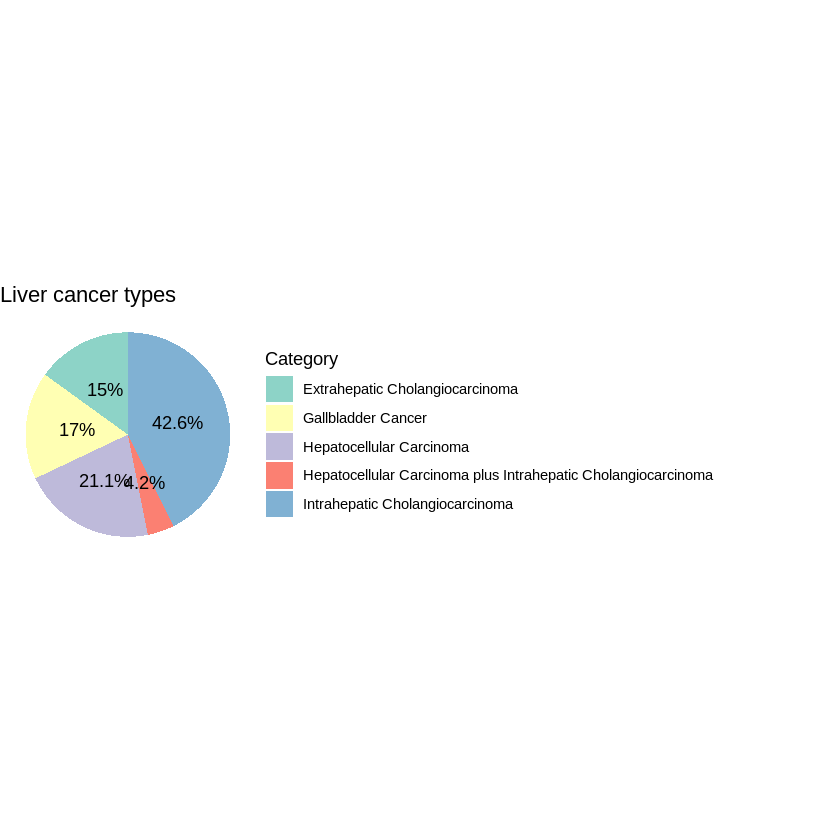

In [31]:
# Pie chart

# Importing library
library(ggplot2)

data_summary <- clinical_record_imputed %>%
  count(Cancer.Type.Detailed) %>%
  mutate(percentage = n / sum(n) * 100)

# Creating pie chart
ggplot(data_summary, aes(x = "", y = n, fill = Cancer.Type.Detailed)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar(theta = "y") +
  theme_void() +
  labs(fill = "Category") +
  scale_fill_brewer(palette = "Set3") +
  geom_text(aes(label = paste0(round(percentage, 1), "%")),
            position = position_stack(vjust = 0.5)) +
  ggtitle("Liver cancer types") # Setting title

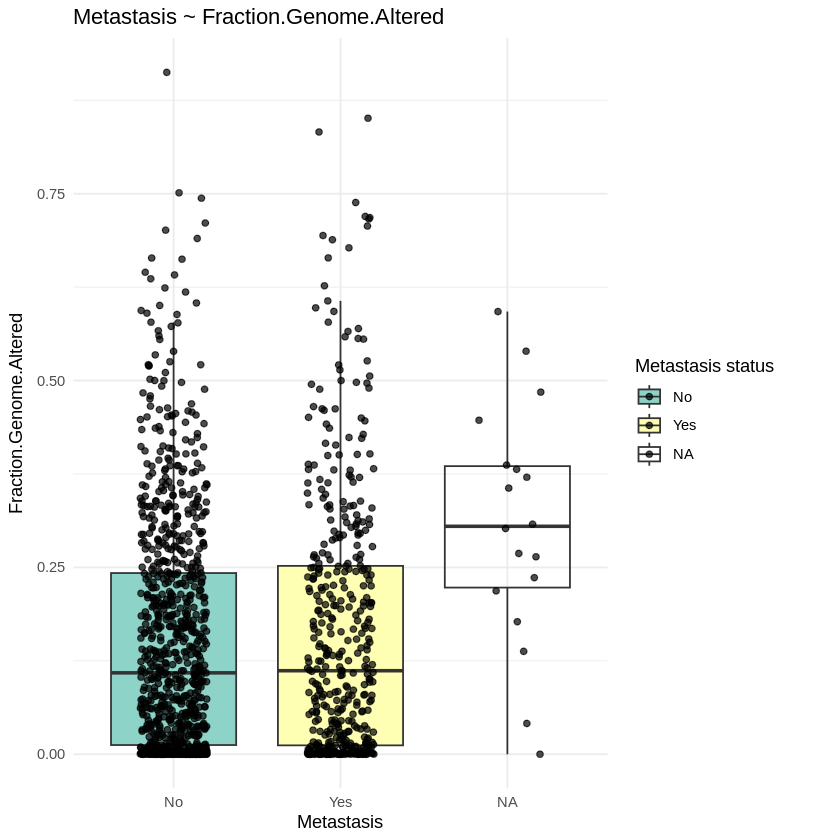

In [32]:
# Boxplot genome altered dan metastasis
ggplot(clinical_record_imputed, aes(x = Metastasis, y = Fraction.Genome.Altered, fill = Metastasis)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(color = "black", size = 1.5, width = 0.2, alpha = 0.7) +
  scale_fill_brewer(palette = "Set3") +
  theme_minimal() +
  labs(x = "Metastasis", y = "Fraction.Genome.Altered", fill = "Metastasis status") +  # Setting Label X, Label Y, and legend
  ggtitle("Metastasis ~ Fraction.Genome.Altered")  # Setting title


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Warning message in cor(numeric, use = "complete.obs"):
“the standard deviation is zero”
Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_text()`).”


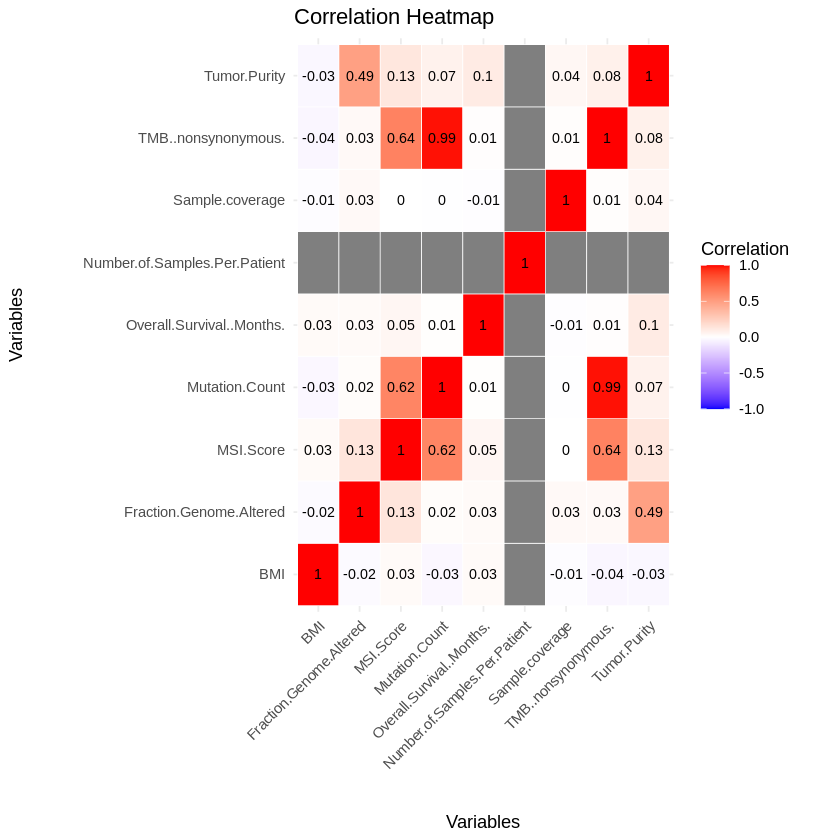

In [33]:
# correlation heatmap

# Importing library
library(reshape2)
numeric <- clinical_record_imputed[, sapply(clinical_record_imputed, is.numeric)]

# Creating correlation matrix
cor_matrix <- cor(numeric, use = "complete.obs")
cor_melted <- melt(cor_matrix)

# Creating Heatmap
ggplot(cor_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(value, 2)), color = "black", size = 3) +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0, limit = c(-1, 1), space = "Lab", name = "Correlation") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  labs(title = "Correlation Heatmap", x = "Variables", y = "Variables")

Tumor mutation burden (TMB) is the number of genetic mutations present in the DNA of cancer cells.

Now, we will create a scatter plot between Mutations.Count (X-axis) and TMB..nonsynonymous (Y-axis).

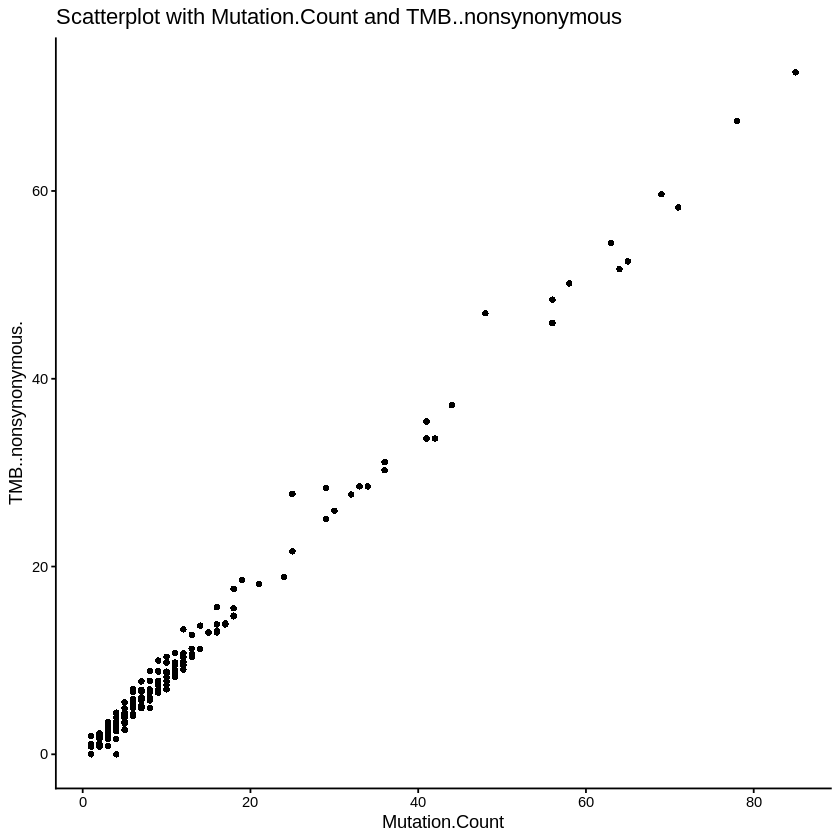

In [34]:
# Scatter plot
ggplot(clinical_record_imputed, aes(x = Mutation.Count, y = TMB..nonsynonymous.)) +
  geom_point(shape = 16, color = "black") +
  theme_classic() +
  labs(x = "Mutation.Count", y = "TMB..nonsynonymous.", title = "Scatterplot with Mutation.Count and TMB..nonsynonymous")

Questin: Visually, what type of regression fits the data?
Answer: Linear regression

Now, we do a linear regression analysis between mutations and TMB

In [35]:
# Linear regression
regression <- lm(TMB..nonsynonymous. ~ Mutation.Count, data = clinical_record_imputed) # ganti nilai y dengan TMB..nonsynonymous., X dengan Mutation.Count, dan df dengan clinical_record_imputed
summary(regression)


Call:
lm(formula = TMB..nonsynonymous. ~ Mutation.Count, data = clinical_record_imputed)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.2374  0.0440  0.2142  0.2648  6.4846 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -0.192531   0.032749  -5.879 5.18e-09 ***
Mutation.Count  0.857473   0.003782 226.733  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9726 on 1368 degrees of freedom
Multiple R-squared:  0.9741,	Adjusted R-squared:  0.9741 
F-statistic: 5.141e+04 on 1 and 1368 DF,  p-value: < 2.2e-16


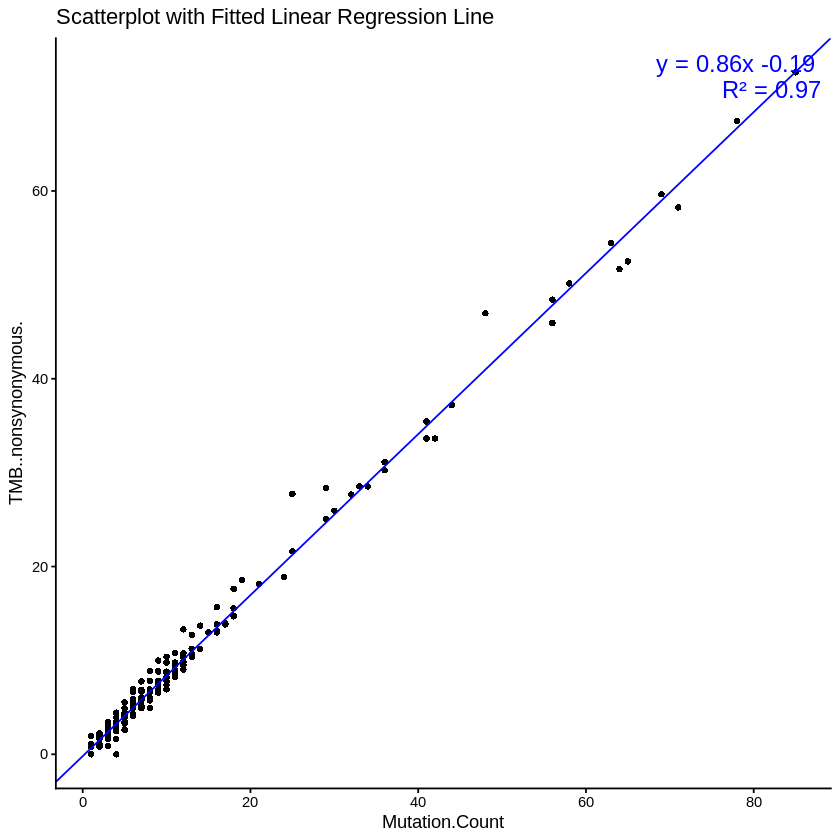

In [36]:
# Plotting linear regression on a scatter plot

intercept <- coef(regression)[1]
slope <- coef(regression)[2]
r_squared <- summary(regression)$r.squared

equation_text <- paste0("y = ", round(slope, 2), "x ", round(intercept, 2))
r_squared_text <- paste0("R² = ", round(r_squared, 2))

ggplot(clinical_record_imputed, aes(x = Mutation.Count , y = TMB..nonsynonymous. )) +
  geom_point(shape = 16, color = "black") +  # Circular black points
  geom_abline(intercept = intercept, slope = slope, color = "blue") +  # Add fitted regression line
  theme_classic() +  # Baseline axes without grid lines
  labs(x = "Mutation.Count", y = "TMB..nonsynonymous.", title = "Scatterplot with Fitted Linear Regression Line") +
  # Add equation and R-squared as text annotations
  annotate("text", x = Inf, y = Inf, label = equation_text, hjust = 1.1, vjust = 2, size = 5, color = "blue") +
  annotate("text", x = Inf, y = Inf, label = r_squared_text, hjust = 1.1, vjust = 3.5, size = 5, color = "blue")

## **Section 3: Multiple Sequence Alignment**

Influenza A has a hemagglutinin receptor protein. Influenza is a virus with a high mutation rate, so analyzing changes in this protein sequence is necessary each year.

Viki was asked to perform multiple sequence alignment (MSA) to examine the mutation patterns in the hemagglutinin protein across influenza variants. She used the Bioconductor repository and analyzed the results with the "BiocManager" package. Ensure that seqinr, msa, ape, and Biostrings are installed.

In [37]:
# Let's call the following libraries (seqinr, msa, ape, Biostrings)
library(seqinr)
library(msa)
library(ape)
library(Biostrings)


Attaching package: ‘seqinr’


The following object is masked from ‘package:dplyr’:

    count


The following object is masked from ‘package:Biostrings’:

    translate



Attaching package: ‘ape’


The following objects are masked from ‘package:seqinr’:

    as.alignment, consensus


The following object is masked from ‘package:dplyr’:

    where


The following object is masked from ‘package:Biostrings’:

    complement




**Reading the dataset (fasta format)**

Read the downloaded fasta file "influenza_hemagglutinin.fasta" and save it as an object named myseq. Make sure the fasta file is in the same directory.


In [38]:
# Downloading dataset
# URL for the influenza_hemagglutinin.fasta"   file
url_github_fasta <- 'https://raw.githubusercontent.com/harishmuh/R_tutorial/refs/heads/main/datasets/influenza_hemagglutinin.fasta'

# Define the local file path where we want to save the dataset
local_file_path <- 'influenza_hemagglutinin.fasta'

# Download the file
download.file(url_github_fasta, destfile = local_file_path, method = 'auto')

In [39]:
# Define the variable for downloaded file
myseq  <- readAAStringSet("influenza_hemagglutinin.fasta")
myseq

AAStringSet object of length 20:
     width seq                                              names               
 [1]   564 MKVKLLILLCALSTTNADTICIG...VTLGAISFWMCSNGSLQCRICI QOR32089.1 hemagg...
 [2]   566 MKAKLFILFCAFTALKADTICVG...VSLGAISFWMCSNGSLQCRICI QOR32099.1 hemagg...
 [3]   566 MKAKLFILFCAFTALKADTICVG...VSLGAISFWMCSNGSLQCRICI QOR32109.1 hemagg...
 [4]   565 MKAKLFVLFCAFNALKADTICIG...VSLGAISFWMCSNGSLQCRICI QOR32119.1 hemagg...
 [5]   566 MKAKLFILFCAFTALKADTICVG...VSLGAISFWMCSNGSLQCRICI QOY39391.1 hemagg...
 ...   ... ...
[16]   564 MKAKLLILLCVLSATDADTICIG...VSLGAISFWMCANGSLQCRICI QOY39388.1 hemagg...
[17]   566 MKAKLFVLFCAFTALKADTICVG...VSLGAISFWMCSNGSLQCRICI QOY39401.1 hemagg...
[18]   566 MEAKMFVLFSAFTALKADTICVG...VSLGAISFWMCSNGSLQCRICI QOR30793.1 hemagg...
[19]   564 MKAKLLILLCALSTTDADTICIG...VSLGAIGFWMCSNGSLQCRICI QOR30783.1 hemagg...
[20]   567 MENIVLLLAIVSLVKSDQICIGY...IMIAGLSLWMCSNGSLQCRICI UXW95750.1 hemagg...

**Multiple Sequence Alignment**

Perform a Multiple Sequence Alignment using the results from the previous reading of the "s_gene.fasta" file. Save it in an object named my_alignment.

In [40]:
# Multiple sequence alignment (MSA)
my_alignment <- msa(myseq, method="ClustalW") # Select the ClustalW method
print(my_alignment, show = 'complete') # Display the complete sequence

use default substitution matrix

MsaAAMultipleAlignment with 20 rows and 578 columns
     aln (1..53)                                           names
 [1] MKAKLLILLCALSTADAD---------TICIGYHANNSTDTVDTVLEKNVTVT QRV12652.1 hemagg...
 [2] MKVKLLILLCTLSTADAD---------TICIGYHANNSTDTVDTVLEKNVTVT QRV12882.1 hemagg...
 [3] MKAKLLILLCALSTADAD---------TICIGYHANNSTDTVDTVLEKNVTVT QRV12766.1 hemagg...
 [4] MKAKLLILLCALSTTDAD---------TICIGYHANNSTDTVDTVLEKNVTVT QOR30783.1 hemagg...
 [5] MKVKLLILLCALSTTNAD---------TICIGYHANNSTDTVDTVLEKNVTVT QOR32089.1 hemagg...
 [6] MKAKLLILLCVLSATDAD---------TICIGYHANNSTDTVDTVLEKNVTVT QOY39388.1 hemagg...
 [7] MEAKLFVLFSIFTALKAD---------TICVGYHANNSTDTVDTILEKNVTVT QPB44068.1 hemagg...
 [8] MEAKMFVLFSAFTALKAD---------TICVGYHANNSTDTVDTILEKNVTVT QOR30793.1 hemagg...
 [9] MEVKLFVLFCSFTAIKAD---------TICVGYHANNSTDTVDTILEKNVTVT QRV12995.1 hemagg... 
 ... ...
[13] MKAKLFILFCTFTALKAD---------TICVGYHANNSTDTVDTILEKNVTVT QOY39419.1 hemagg...
[14] MKAKLFVLFCAFTALKAD---------TICVGYHA

 Viki wanted to create an epitope model for vaccine design that could detect all twenty variants simultaneously. She need to create consensus sequence. The consensus sequence is the sequence resulting from the alignment process, consisting of a single sequence.


Display the sequence from the previous process

In [41]:
# Alignment result
aligned_seq <- as(my_alignment, "AAStringSet")
selected_seq <- consensusString(aligned_seq)
print(selected_seq)

[1] "MKAKLFILFCAFTALKAD---------TICVGYHANNSTDTVDTILEKNVTVTHSVNLLENSHNGKLCSLNGKAPLQLGNCNVAGWILGNPECD?L?TANSWSYIIETSNSKNG?CYPGEF?DYEELREQLS?VSSFERFEIFPK?TSWP?H?TTKG?T?ACSHSG??SFYRNLLWIVKK?NSYPKLS?SYTNNKGKEVLVIWGVHHPPTDSDQQTLYQNNHTYVSV?SSKYY?RFTPEIV?RPKIR?QAGRMNYYWTLLDQGDTITFEATGNLIAPWYAFAL?KGS?SGIM?SDA?VHNCTTKCQTPHGALKSNLPFQNVHPITIGECPKYVKSTQLRMATGLRNIPSIQSR---GLFGAIAGFIEGGWTGMIDGWYGYHHQNEQGSGYAADQKSTQIAIDGISNKVNSVIEKMNIQFTSVGKEFNNLEKRIENLNKKVDDGFLDVWTYNAELLILLENERTLDFHD?NVKNLYEKVKSQLRNNAKEIGNGCFEFYHKCDNECMESVKNGTYNYPKYSEESKLNRE?IDGVKLESMGVYQILAIYSTVASSLVLLVSLGAISFWMCSNGSLQCRICI"


**Phylogenetic tree**

Viki wants to construct a phylogenetic tree with Neighbor Joining to see the kinship between the virus variants using the previous multiple sequence alignment results! To convert the MSA result format to a format for phylogenetic tree construction, follow the example below!

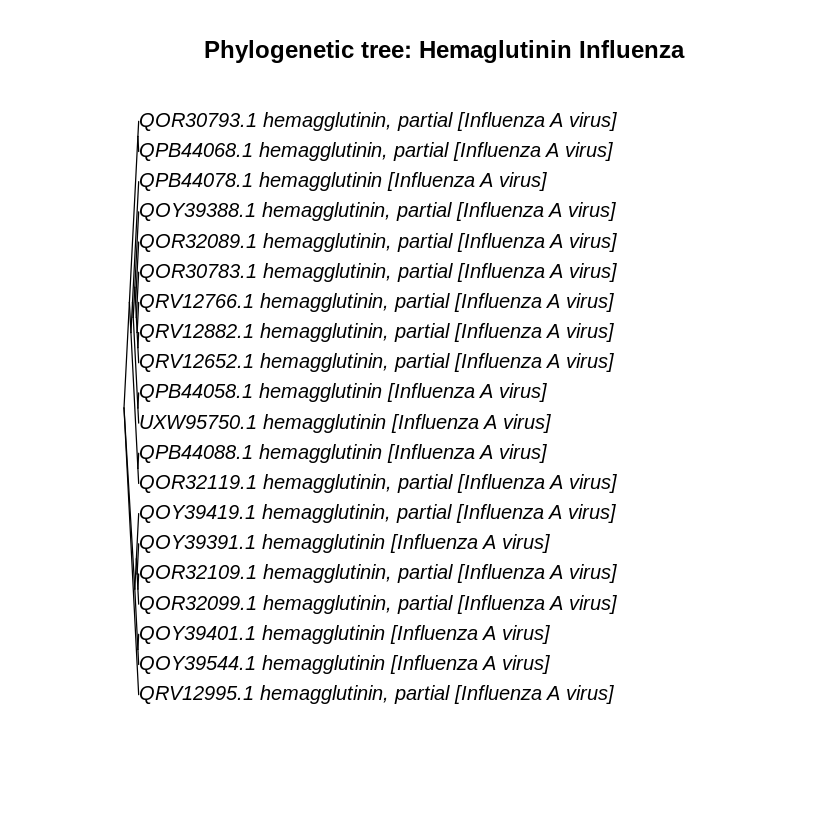

In [42]:
# Conversion
mytree <- msaConvert(my_alignment, type="seqinr::alignment")
gd <- dist.alignment(mytree, "identity")
build_tree <- nj(gd)
plot(build_tree, main="Phylogenetic tree: Hemaglutinin Influenza", "c", FALSE) # setting title

Question: Why does Viki consider Neighbor Joining over other methods?

* Answer: Viki considers evolutionary distance more because they want to see kinship, not character-based (character-based is usually used for similar characters).

**How to save the file?**

Save your file with Ctrl + S

Then, save your workspace with:
save.image('your_workspace.RData')

In [43]:
save.image('workspace_HM.RData')

Check the libraries used with:
sessionInfo()

In [44]:
# session info
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ape_5.8-1           msa_1.42.0          seqinr_4.2-36      
 [4] reshape2_1.4.5      ggplot2_4.0.3       tidyr_1.3.2        
 [7] dplyr_1.2.1         Biostrings

## **Conclusion**

This notebook has covered the fundamental bioinformatic analysis techniques in R and a practical application to liver cancer clinical data. We successfully performed:

*   **Basic DNA Sequence Operations**: Demonstrated sequence manipulation using the Biostrings package, including subsequence extraction and length calculation.
*   **Clinical Data Preprocessing**: Acquired, cleaned, and imputed missing values in a liver cancer clinical dataset, ensuring data quality for analysis.
*   **Clinical Data Analysis & Visualization**: Generated various plots like pie charts, boxplots, correlation heatmaps, and scatter plots with linear regression to explore and understand the clinical data.
*   **Multiple Sequence Alignment (MSA)**: Performed MSA on influenza hemagglutinin sequences using ClustalW, derived a consensus sequence, and constructed a phylogenetic tree to analyze evolutionary relationships.